In [ ]:
!pip -q install gin-config

import os
import json
import math
import random
import textwrap
from pathlib import Path

import gin
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


ROOT = Path("/content/gin_config_sharp_tutorial")
CONFIG_DIR = ROOT / "configs"
RUN_DIR = ROOT / "runs"

CONFIG_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

gin.clear_config()


@gin.configurable
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    return seed


@gin.configurable
def make_spiral_dataset(
    n_per_class=gin.REQUIRED,
    noise=0.18,
    rotations=1.75,
    train_fraction=0.8,
    seed=0,
):
    rng = np.random.default_rng(seed)

    radius_0 = np.linspace(0.05, 1.0, n_per_class)
    theta_0 = rotations * 2 * np.pi * radius_0
    theta_0 += rng.normal(0.0, noise, size=n_per_class)

    x0 = np.stack(
        [
            radius_0 * np.cos(theta_0),
            radius_0 * np.sin(theta_0),
        ],
        axis=1,
    )

    radius_1 = np.linspace(0.05, 1.0, n_per_class)
    theta_1 = rotations * 2 * np.pi * radius_1 + np.pi
    theta_1 += rng.normal(0.0, noise, size=n_per_class)

    x1 = np.stack(
        [
            radius_1 * np.cos(theta_1),
            radius_1 * np.sin(theta_1),
        ],
        axis=1,
    )

    x = np.concatenate([x0, x1], axis=0).astype(np.float32)
    y = np.concatenate(
        [
            np.zeros((n_per_class, 1)),
            np.ones((n_per_class, 1)),
        ],
        axis=0,
    ).astype(np.float32)

    order = rng.permutation(len(x))
    x = x[order]
    y = y[order]

    split = int(train_fraction * len(x))

    x_train, y_train = x[:split], y[:split]
    x_val, y_val = x[split:], y[split:]

    mean = x_train.mean(axis=0, keepdims=True)
    std = x_train.std(axis=0, keepdims=True) + 1e-8

    x_train = (x_train - mean) / std
    x_val = (x_val - mean) / std

    return {
        "train": (
            torch.tensor(x_train),
            torch.tensor(y_train),
        ),
        "val": (
            torch.tensor(x_val),
            torch.tensor(y_val),
        ),
        "metadata": {
            "n_train": int(len(x_train)),
            "n_val": int(len(x_val)),
            "n_features": int(x_train.shape[1]),
            "noise": float(noise),
            "rotations": float(rotations),
            "seed": int(seed),
        },
    }


@gin.configurable(denylist=["x", "y"])
def make_loader(
    x,
    y,
    batch_size=128,
    shuffle=True,
    seed=0,
):
    generator = torch.Generator()
    generator.manual_seed(seed)

    dataset = TensorDataset(x, y)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        drop_last=False,
    )

In [ ]:
def activation_layer(name):
    name = name.lower()

    if name == "relu":
        return nn.ReLU()

    if name == "gelu":
        return nn.GELU()

    if name == "tanh":
        return nn.Tanh()

    if name == "silu":
        return nn.SiLU()

    raise ValueError(f"Unknown activation: {name}")


@gin.configurable
class MLP(nn.Module):
    def __init__(
        self,
        input_dim=gin.REQUIRED,
        hidden_dims=(64, 64),
        output_dim=1,
        activation="gelu",
        dropout=0.0,
        use_layernorm=False,
    ):
        super().__init__()

        layers = []
        current_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(current_dim, hidden_dim))

            if use_layernorm:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(activation_layer(activation))

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, output_dim))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


@gin.configurable(denylist=["params"])
def make_optimizer(
    params,
    name="adamw",
    lr=3e-3,
    weight_decay=1e-3,
    momentum=0.9,
):
    name = name.lower()

    if name == "adamw":
        return torch.optim.AdamW(
            params,
            lr=lr,
            weight_decay=weight_decay,
        )

    if name == "sgd":
        return torch.optim.SGD(
            params,
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay,
        )

    raise ValueError(f"Unknown optimizer: {name}")


@gin.configurable(denylist=["optimizer"])
def make_cosine_scheduler(
    optimizer,
    total_epochs=60,
    warmup_epochs=5,
    min_lr_factor=0.05,
):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(max(1, warmup_epochs))

        progress = (epoch - warmup_epochs) / float(
            max(1, total_epochs - warmup_epochs)
        )

        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return min_lr_factor + (1.0 - min_lr_factor) * cosine

    return torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lr_lambda,
    )


@gin.configurable
def bce_with_logits_loss(
    logits,
    targets,
    label_smoothing=0.0,
):
    if label_smoothing > 0:
        targets = targets * (1.0 - label_smoothing) + 0.5 * label_smoothing

    return F.binary_cross_entropy_with_logits(logits, targets)


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = loss_fn(logits, y)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        total_loss += loss.item() * len(x)
        total_correct += (preds == y).sum().item()
        total_count += len(x)

    return {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count,
    }

In [ ]:
@gin.configurable(
    denylist=[
        "model",
        "optimizer",
        "scheduler",
        "train_loader",
        "val_loader",
        "device",
    ]
)
def fit(
    model,
    optimizer,
    scheduler,
    train_loader,
    val_loader,
    device,
    epochs=60,
    grad_clip_norm=1.0,
    log_every=10,
    loss_fn=bce_with_logits_loss,
):
    history = []

    for epoch in range(1, epochs + 1):
        model.train()

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(x)
            loss = loss_fn(logits, y)

            loss.backward()

            if grad_clip_norm is not None:
                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    grad_clip_norm,
                )

            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        train_metrics = evaluate(
            model,
            train_loader,
            loss_fn,
            device,
        )

        val_metrics = evaluate(
            model,
            val_loader,
            loss_fn,
            device,
        )

        lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "lr": lr,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
        }

        history.append(row)

        if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
            print(
                f"epoch={epoch:03d} | "
                f"lr={lr:.6f} | "
                f"train_loss={row['train_loss']:.4f} | "
                f"train_acc={row['train_accuracy']:.3f} | "
                f"val_loss={row['val_loss']:.4f} | "
                f"val_acc={row['val_accuracy']:.3f}"
            )

    return history


@gin.configurable
def run_experiment(
    tag=gin.REQUIRED,
    model=gin.REQUIRED,
    dataset_fn=make_spiral_dataset,
    optimizer_factory=make_optimizer,
    scheduler_factory=make_cosine_scheduler,
    prefer_gpu=True,
):
    seed_everything()

    device = "cuda" if prefer_gpu and torch.cuda.is_available() else "cpu"

    data = dataset_fn()

    x_train, y_train = data["train"]
    x_val, y_val = data["val"]

    train_loader = make_loader(
        x_train,
        y_train,
        shuffle=True,
    )

    val_loader = make_loader(
        x_val,
        y_val,
        shuffle=False,
    )

    model = model.to(device)

    optimizer = optimizer_factory(model.parameters())

    scheduler = None
    if scheduler_factory is not None:
        scheduler = scheduler_factory(optimizer)

    print("\n" + "=" * 80)
    print(f"Experiment: {tag}")
    print("=" * 80)
    print(f"Device: {device}")
    print(f"Dataset: {data['metadata']}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

    history = fit(
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
    )

    result = {
        "tag": tag,
        "device": device,
        "metadata": data["metadata"],
        "parameters": sum(p.numel() for p in model.parameters()),
        "final": history[-1],
        "history": history,
    }

    return result

In [ ]:
BASE_CONFIG = CONFIG_DIR / "base.gin"
COMPACT_CONFIG = CONFIG_DIR / "compact_adamw.gin"
WIDE_CONFIG = CONFIG_DIR / "wide_sgd.gin"

BASE_CONFIG.write_text(
    textwrap.dedent(
        """
        SEED = 123
        N_PER_CLASS = 900
        EPOCHS = 50
        BATCH = 128

        seed_everything.seed = %SEED

        make_spiral_dataset.n_per_class = %N_PER_CLASS
        make_spiral_dataset.noise = 0.20
        make_spiral_dataset.rotations = 1.85
        make_spiral_dataset.train_fraction = 0.80
        make_spiral_dataset.seed = %SEED

        make_loader.batch_size = %BATCH
        make_loader.seed = %SEED

        MLP.input_dim = 2
        MLP.output_dim = 1
        MLP.activation = 'gelu'
        MLP.dropout = 0.05
        MLP.use_layernorm = True

        make_optimizer.name = 'adamw'
        make_optimizer.lr = 0.003
        make_optimizer.weight_decay = 0.001
        make_optimizer.momentum = 0.9

        make_cosine_scheduler.total_epochs = %EPOCHS
        make_cosine_scheduler.warmup_epochs = 5
        make_cosine_scheduler.min_lr_factor = 0.05

        bce_with_logits_loss.label_smoothing = 0.02

        fit.epochs = %EPOCHS
        fit.grad_clip_norm = 1.0
        fit.log_every = 10
        fit.loss_fn = @bce_with_logits_loss

        run_experiment.dataset_fn = @make_spiral_dataset
        run_experiment.optimizer_factory = @make_optimizer
        run_experiment.scheduler_factory = @make_cosine_scheduler
        run_experiment.prefer_gpu = True
        """
    ).strip()
)

COMPACT_CONFIG.write_text(
    textwrap.dedent(
        f"""
        include '{BASE_CONFIG.as_posix()}'

        run_experiment.tag = 'compact_gelu_adamw'
        run_experiment.model = @compact/MLP()

        compact/MLP.hidden_dims = (64, 64, 64)
        compact/MLP.dropout = 0.05
        compact/MLP.use_layernorm = True

        make_optimizer.name = 'adamw'
        make_optimizer.lr = 0.003
        make_optimizer.weight_decay = 0.001
        """
    ).strip()
)

WIDE_CONFIG.write_text(
    textwrap.dedent(
        f"""
        include '{BASE_CONFIG.as_posix()}'

        run_experiment.tag = 'wide_relu_sgd'
        run_experiment.model = @wide/MLP()

        wide/MLP.hidden_dims = (128, 128, 128, 64)
        wide/MLP.activation = 'relu'
        wide/MLP.dropout = 0.02
        wide/MLP.use_layernorm = True

        make_optimizer.name = 'sgd'
        make_optimizer.lr = 0.035
        make_optimizer.momentum = 0.92
        make_optimizer.weight_decay = 0.0005

        bce_with_logits_loss.label_smoothing = 0.0
        """
    ).strip()
)


def run_from_gin_file(config_path, runtime_bindings=None):
    runtime_bindings = runtime_bindings or []

    gin.clear_config()

    gin.parse_config_files_and_bindings(
        config_files=[str(config_path)],
        bindings=runtime_bindings,
        skip_unknown=False,
        finalize_config=True,
    )

    print("\nLoaded config file:")
    print(config_path)

    print("\nSelected queried parameters:")
    print("fit.epochs =", gin.query_parameter("fit.epochs"))
    print("make_loader.batch_size =", gin.query_parameter("make_loader.batch_size"))
    print("make_spiral_dataset.noise =", gin.query_parameter("make_spiral_dataset.noise"))

    try:
        gin.bind_parameter("fit.epochs", 999)
    except RuntimeError as error:
        print("\nConfig lock check:")
        print(str(error).splitlines()[0])

    result = run_experiment()

    tag = result["tag"]
    out_dir = RUN_DIR / tag
    out_dir.mkdir(parents=True, exist_ok=True)

    result_path = out_dir / "result.json"
    operative_path = out_dir / "operative_config.gin"

    result_path.write_text(json.dumps(result, indent=2))
    operative_path.write_text(gin.operative_config_str())

    print("\nSaved:")
    print(result_path)
    print(operative_path)

    return result, operative_path


compact_result, compact_operative = run_from_gin_file(
    COMPACT_CONFIG,
    runtime_bindings=[
        "fit.epochs = 45",
        "make_spiral_dataset.noise = 0.18",
        "run_experiment.tag = 'compact_gelu_adamw_runtime_override'",
    ],
)

wide_result, wide_operative = run_from_gin_file(
    WIDE_CONFIG,
    runtime_bindings=[
        "fit.epochs = 45",
        "make_spiral_dataset.noise = 0.18",
        "run_experiment.tag = 'wide_relu_sgd_runtime_override'",
    ],
)


Loaded config file:
/content/gin_config_sharp_tutorial/configs/compact_adamw.gin

Selected queried parameters:
fit.epochs = 45
make_loader.batch_size = %BATCH
make_spiral_dataset.noise = 0.18

Config lock check:
Attempted to modify locked Gin config.

Experiment: compact_gelu_adamw_runtime_override
Device: cpu
Dataset: {'n_train': 1440, 'n_val': 360, 'n_features': 2, 'noise': 0.18, 'rotations': 1.85, 'seed': 42}
Parameters: 8,961
epoch=001 | lr=0.001200 | train_loss=0.6730 | train_acc=0.609 | val_loss=0.6656 | val_acc=0.628
epoch=010 | lr=0.002914 | train_loss=0.1153 | train_acc=0.985 | val_loss=0.1101 | val_acc=0.986
epoch=020 | lr=0.002288 | train_loss=0.0631 | train_acc=0.997 | val_loss=0.0584 | val_acc=1.000
epoch=030 | lr=0.001328 | train_loss=0.0575 | train_acc=1.000 | val_loss=0.0574 | val_acc=1.000
epoch=040 | lr=0.000483 | train_loss=0.0574 | train_acc=1.000 | val_loss=0.0574 | val_acc=1.000
epoch=045 | lr=0.000236 | train_loss=0.0574 | train_acc=1.000 | val_loss=0.0573 | val

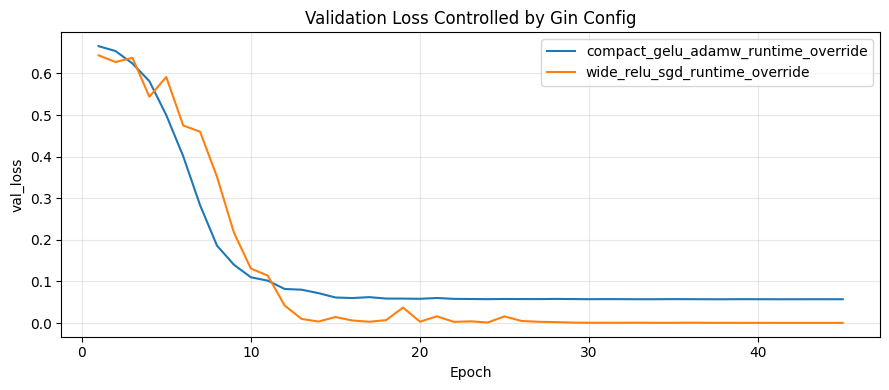

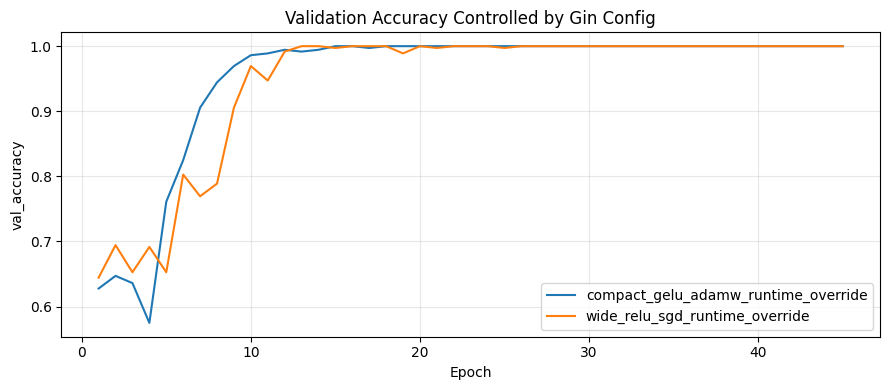


Final comparison
compact_gelu_adamw_runtime_override | params=8,961 | val_loss=0.0573 | val_acc=1.000
wide_relu_sgd_runtime_override | params=42,625 | val_loss=0.0005 | val_acc=1.000

Compact experiment operative config preview
# Macros:
# ==============================================================================
BATCH = 128
EPOCHS = 50
N_PER_CLASS = 900

# Parameters for bce_with_logits_loss:
# ==============================================================================
bce_with_logits_loss.label_smoothing = 0.02

# Parameters for fit:
# ==============================================================================
fit.epochs = 45
fit.grad_clip_norm = 1.0
fit.log_every = 10
fit.loss_fn = @bce_with_logits_loss

# Parameters for make_cosine_scheduler:
# ==============================================================================
make_cosine_scheduler.min_lr_factor = 0.05
make_cosine_scheduler.total_epochs = %EPOCHS
make_cosine_scheduler.warmup_epochs = 5

# Parameters for make_

In [4]:
def plot_metric(results, metric, title):
    plt.figure(figsize=(9, 4))

    for result in results:
        epochs = [row["epoch"] for row in result["history"]]
        values = [row[metric] for row in result["history"]]
        plt.plot(epochs, values, label=result["tag"])

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_metric(
    [compact_result, wide_result],
    "val_loss",
    "Validation Loss Controlled by Gin Config",
)

plot_metric(
    [compact_result, wide_result],
    "val_accuracy",
    "Validation Accuracy Controlled by Gin Config",
)


summary = [
    {
        "tag": compact_result["tag"],
        "params": compact_result["parameters"],
        "val_loss": compact_result["final"]["val_loss"],
        "val_accuracy": compact_result["final"]["val_accuracy"],
    },
    {
        "tag": wide_result["tag"],
        "params": wide_result["parameters"],
        "val_loss": wide_result["final"]["val_loss"],
        "val_accuracy": wide_result["final"]["val_accuracy"],
    },
]

print("\n" + "=" * 80)
print("Final comparison")
print("=" * 80)

for row in summary:
    print(
        f"{row['tag']} | "
        f"params={row['params']:,} | "
        f"val_loss={row['val_loss']:.4f} | "
        f"val_acc={row['val_accuracy']:.3f}"
    )

print("\n" + "=" * 80)
print("Compact experiment operative config preview")
print("=" * 80)
print(compact_operative.read_text()[:2500])

print("\n" + "=" * 80)
print("Generated files")
print("=" * 80)
for path in sorted(ROOT.rglob("*")):
    if path.is_file():
        print(path)